**Disciplina: ACA052 - Meteorología Sinótica I**

Monitor: M.Sc Student Ronald Guiuseppi Ramírez Nina

Institute of Astronomy, Geophysics and Atmospheric Sciences - University of São Paulo, Brazil

File: Aula_01.ipynb


**Objetivos**
- Conhecer sobre os arquivos do tipo NetCDF
- Fazer plots dos dados meteorológicos do NCEP-NOAA (Reanalise 2)

**O são os arquivos NetCDF?**

O NetCDF (NETwork Common Data Form) é um tipo de arquivo para armazenamento multi-dimensional de dados científicos (variáveis), e.g. temperatura, umidade, pressão, velocidade e direção do vento. Os dados em formato NetCDF são:
- Auto-descriptivos: Inclui informações sobre os dados que contém.
- Portátil: Podem ser acessados por computadores com diferentes maneiras de armazenar inteiros, caracteres e números de ponto flotante. 
- Escalável: Pequenos subconjuntos de grandes conjuntos de dados em vários formatos podem ser acessados de forma eficiente por meio de interfaces NetCDF, mesmo de servidores remotos.
- Anexável: Os dados podem ser anexados a um arquivo NetCDF adequadamente estruturado sem copiar o conjunto de dados ou definir sua estrutura.
- Compartilhável: Um gravador e vários leitores podem acessar simultáneamente o mesmo arquivo NetCDF.
- Arquivável: O acesso a todas as formas anteriores de dados NetCDF será suportado por versões atuais e futuras do software. 

Para saber mais acerca de dados NetCD <- https://www.unidata.ucar.edu/software/netcdf/


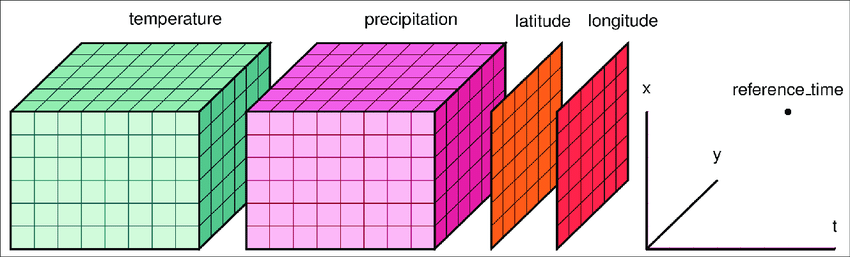

**NCEP**: National Centers for Environmental Prediction

**NCAR**: National Center for Atmoispheric Research

**NOAA**: National Oceanic and Atmospheric Administration


---


**Asimilação de dados**

É um conjunto de técnicas empregadas para realizar adequadamente a inserção de dados de observação num sistema operacional de previsão. Na meteorologia, é um procedimento que consiste em corrigir, com ajuda de observações (in situ, sensoramento remoto, etc), o estado da atmósfera de uma previsão meteorológica. 

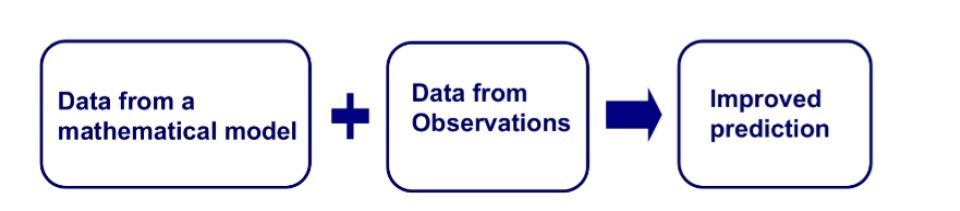

**Análise de dados operacionais**

É o melhor ajuste do modelo numérico aos dados disponíveis, levando em consideração os erros do modelo e dos dados.



**Reanálise atmosférica**

É um projeto de assimilação de dados meteorológicos e climáticos que visa assimilar dados observacionais atmosféricos históricos que abrangem um período extenso, usando um único esquema consistente de assimilação em todo.



**Reanalysis 1 NCEP/NCAR**

É um conjunto de dados em grade global continuamente atualizado (1948 até o presente) que representa o estado da atmósfera da Terra, incorporando observações e modelos de previsão numérica do tempo (NWP) de 1948 até o presente. É um produto conjunto dos NCEP e do NCAR.



**Reanalysis 2 NCEP/NCAR**

É uma versão melhorada do modelo NCEP Reanalysis I que ajusta os erros e atualiza as parametrizações dos processos físicos.

 - Cobertura temporal: 4 vecez no dia, dados diários, mensuais desde 1979/01 até 2022/02.
 - Cobertura global: Grade global para várias resoluções.
 - Níveis: 17 Níveis de pressão (hPa) desde 1000 hPa até 10 hPa (Além disso, têm níveis sigma e arquivos de nível único).
 - Atualização: Mensal

Visualizando a lista de pacotes instalados por default no Google Colab. Para isso basta com usar o comando !pip freeze. Já no ambiemte Anaconda o comando a utilizad no terminal é:

usuario$ conda list

In [ ]:
!pip freeze

Instalar o pacote "cartopy", desinstalar o shapely e instalar uma versão compatível com o cartopy para o bom funcionamento no colab.

In [39]:
# Instalando o cartopy, com os pacotes e versões necessárias para o seu bom funcionamento no colab
!pip uninstall -y shapely
!pip install -q netcdf4
!pip install shapely cartopy --no-binary shapely --no-binary cartopy

Found existing installation: Shapely 1.8.1.post1
Uninstalling Shapely-1.8.1.post1:
  Successfully uninstalled Shapely-1.8.1.post1
  Using cached Shapely-1.8.1.post1.tar.gz (198 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Created wheel for shapely: filename=Shapely-1.8.1.post1-cp37-cp37m-linux_x86_64.whl size=665642 sha256=a9136e78e0039c8ea1273f5a8cf1c4d3e2271727785282e57874d355af0fde2a
  Stored in directory: /root/.cache/pip/wheels/ea/8d/2f/ab748b8a432b3c6cd72e751b3bca17c5a9ed4538b1e78467e6
Successfully built shapely
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 0.1.12 requires imgaug<0.2.7,>=0.2.5, but you have imgaug 0.2.9 which is incompatible.


Importar os pacotes necessários para ler, processar e plotar os dados NetCDF do NCEP/NOAA. Montar o drive para acessar a nossa pasta com os dados. 

In [41]:
# Importar as bibliotecas necessárias para o funcionamento do seguinte código

# Importar os pacotes de processamento
print("1. Ler pacotes")
import xarray as xr
import numpy as np

# Importar pacotes de geração de figuras
import matplotlib.pyplot as plt
import cartopy.crs as ccrs # Pacote para mapas (sistema de referência cooordenado)
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import calendar # Pacote para edição de datas

# Importar pacote para montar o drive e ter acesso aos dados em nosso drive
print("2. Montando o drive para acesso aos dados")
from google.colab import drive
drive.mount('/content/drive')

print("3. Terminou de ler os pacotes")

1. Ler pacotes
2. Montando o drive para acesso aos dados
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
3. Terminou de ler os pacotes


Ler o arquivo NetCDF da variável "temperatura do ar a 2 metros da superfície" 

In [ ]:
# Abrindo o arquivo NetCDF que esta em nosso drive
# ds <- data set
print("4. Ler o dataset NetCDF")
ds = xr.open_dataset('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/dados/NCEP-NOAA/air.2m.mon.mean.nc')

# Olhando a informação/descrição do file NetCDF
print("5. Ver a informação/descrição do file NetCDF")
ds

4. Ler o dataset NetCDF
5. Ver a informação/descrição do file NetCDF


<xarray.Dataset>
Dimensions:    (lat: 94, level: 1, lon: 192, nbnds: 2, time: 518)
Coordinates:
  * level      (level) float32 2.0
  * lat        (lat) float32 88.54 86.65 84.75 82.85 ... -84.75 -86.65 -88.54
  * lon        (lon) float32 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] ...
    air        (time, level, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

Fazer um plot para rápido para visualizar as características do dataset: Formato do eixo da latitude, longitude e escala da temperatura.

Utilizar a opção - "selection" (sel) para fazer o plot.

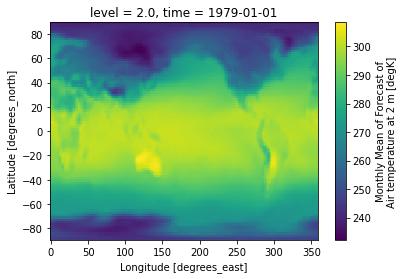

In [ ]:
# Fazendo um plot para dar uma olhada geral dos dados utilizando a opção:
# sel <- selection
# seleccionar a data no formato de string, em nosso caso vai ser 'YYYY-MM-DD'
ds['air'].sel(time='1979-01').plot()

Utilizar a opção - "index selection" (isel) para fazer o plot.

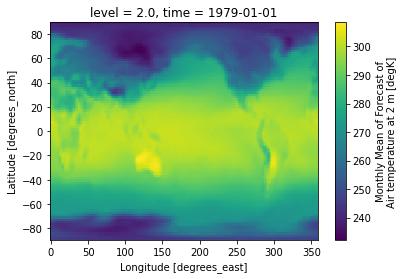

In [ ]:
# Fazendo um plot, mas nesta vez com a opção
# isel <- index selection
# Lembrando que no python os index vai começar no valor 0
ds['air'].isel(time=0).plot()

Antes de continuar, vamos fazer algumas mudanças no formato dos dados:
1. Vamos a transformar o formato das longitudes de 0 a 360º para um formato de -180º a +180º (formato comum na marioria de gráficas nos artigos de meteorología), além de questões práticas no momento de utilizar no pacote "cartopy". Para isso a gente vai editar o objeto 'lon' das coordenadas de ds da forma seguinte:
  - ds.coords['lon'] + 180: 0 a 360 se torna 180 a 540
  - (ds.coords['lon'] + 180) % 360: se calcula o resto da divisão por 360
  - (ds.coords['lon'] + 180) % 360 - 180: Substrai 180 tornando 0,2.5,...,177.5,-180,-177.5,...,-2.5 (se for uma resolução de 2.5º)
  - ds.sortby(ds['lon']): Ordenamos os valores desde o menor valor -180 até o maior valor 177.5. Assim com o sortby se garante que serão ordenados todos os objetos junto com o objeto 'lon'.



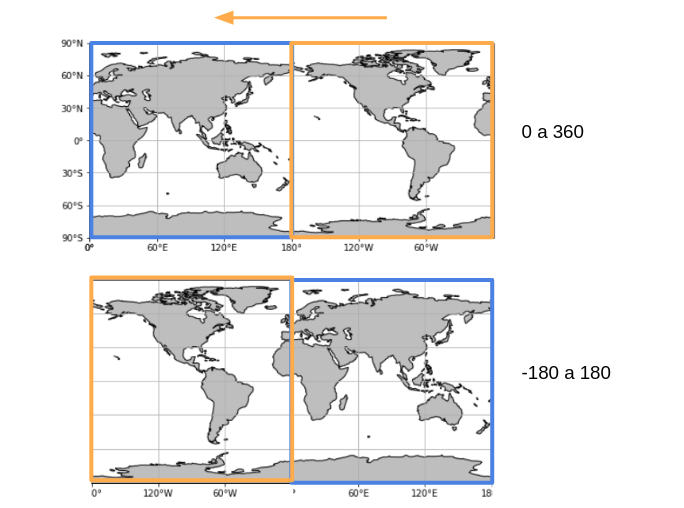

2. Vamos a transforma a escala absoluta da temperatura (Kelvin) para uma escala Celcius. Para isso a gente vai editar o objeto 'air' das variáveis da seguinte forma:
  - ds['air'][ : , : , : , : ] = ds['air'][ : , : , : , : ] - 273.15
  
  Assim, vamos garantir que a conversão vai ser em tudas as dimenssões do datset: latitude, longitude, nível, tempo.

6. Tranformação do formato das longitudes
7. Ordenando o dataset baseado no novo formato da longitude -180º a 180º


<xarray.Dataset>
Dimensions:    (lat: 94, level: 1, lon: 192, nbnds: 2, time: 518)
Coordinates:
  * level      (level) float32 2.0
  * lat        (lat) float32 88.54 86.65 84.75 82.85 ... -84.75 -86.65 -88.54
  * lon        (lon) float32 -180.0 -178.1 -176.2 -174.4 ... 174.4 176.2 178.1
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-03-01
    air        (time, level, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

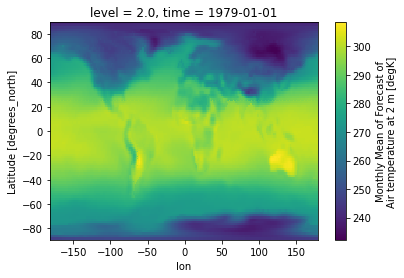

In [ ]:
# Fazendo a transformação do formato das longitudes de 0 a 360º para -180º a +180º
print("6. Tranformação do formato das longitudes")
ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180

# Ordenando o dataset baseado no novo formato da longitude -180º a +180º
print("7. Ordenando o dataset baseado no novo formato da longitude -180º a 180º")
ds = ds.sortby(ds.lon)

# Fazendo um plot para visualizar o novo formato
ds['air'].isel(time=0).plot()
ds

Fazer a transformação da escala da temperatura: de uma escala Kelvin para uma escala Celsius.

8. Fazendo a transformação da escala Kelvin para a escala Celsius(º)
9. Fazendo um plot para ver a transformação da escala


<xarray.Dataset>
Dimensions:    (lat: 94, level: 1, lon: 192, nbnds: 2, time: 518)
Coordinates:
  * level      (level) float32 2.0
  * lat        (lat) float32 88.54 86.65 84.75 82.85 ... -84.75 -86.65 -88.54
  * lon        (lon) float32 -180.0 -178.1 -176.2 -174.4 ... 174.4 176.2 178.1
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-03-01
    air        (time, level, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

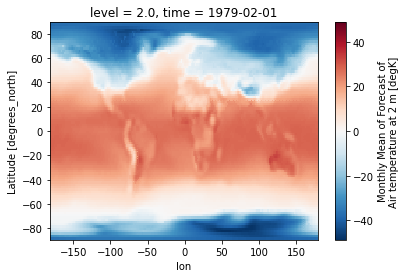

In [ ]:
# Fazendo a transformação da escala da temperatura absoluta (Kelvin) para a escala Celsius
print("8. Fazendo a transformação da escala Kelvin para a escala Celsius(º)")
ds['air'][:,:,:,:] = ds['air'][:,:,:,:] - 273.15

# Fazendo um plot para ver a nova escala nos valores da temperatura
print("9. Fazendo um plot para ver a transformação da escala")
ds['air'].isel(time=1).plot()
ds

Criar o mapa utilizando o pacote "cartopy". Fazer 3 mapas: 

- Primeiro mapa com a opção "contourf" -> Sombreado das magnitudes.
- Segundo mapa com a opção "contou" -> Isolinhas de temperatura.
- Tercer mapa com as duas opções "contourf" e "contour" -> Junta o sombreado e as isolhinas.

10. Criando a figura
11. Criando a figura e estabelecen 3 plots
12. Agregando arrays para formatas os eixos
13. Criando o plot 1
14. Opção de formatação dos eixos
15. Agregando linhas de costa, límites dos paises e os estados
16. Estabelecendo os rango de valores da paleta de cores
17. Criando o gráfico com a opção contourf
18. Agregando título ao plot 1
19. Criando o gráfico com a opção contour
*. Agregando valores aos contornos
20. Agregando título ao plot 2
21. Fazendo um merge das opções contourf e contour
22. Agrendo contourf
23. Agregando contour
24. Agregando título ao plot 3
25. Agregando paleta de cores no médio da figura
26. Agregando supertile à figura
27. Formatando os espaçõs entre os plots e títulos
28. Salavando a figura .png


/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/50m/physical/ne_50m_coastline.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_1_states_provinces_lines.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)


29. Figura salvada


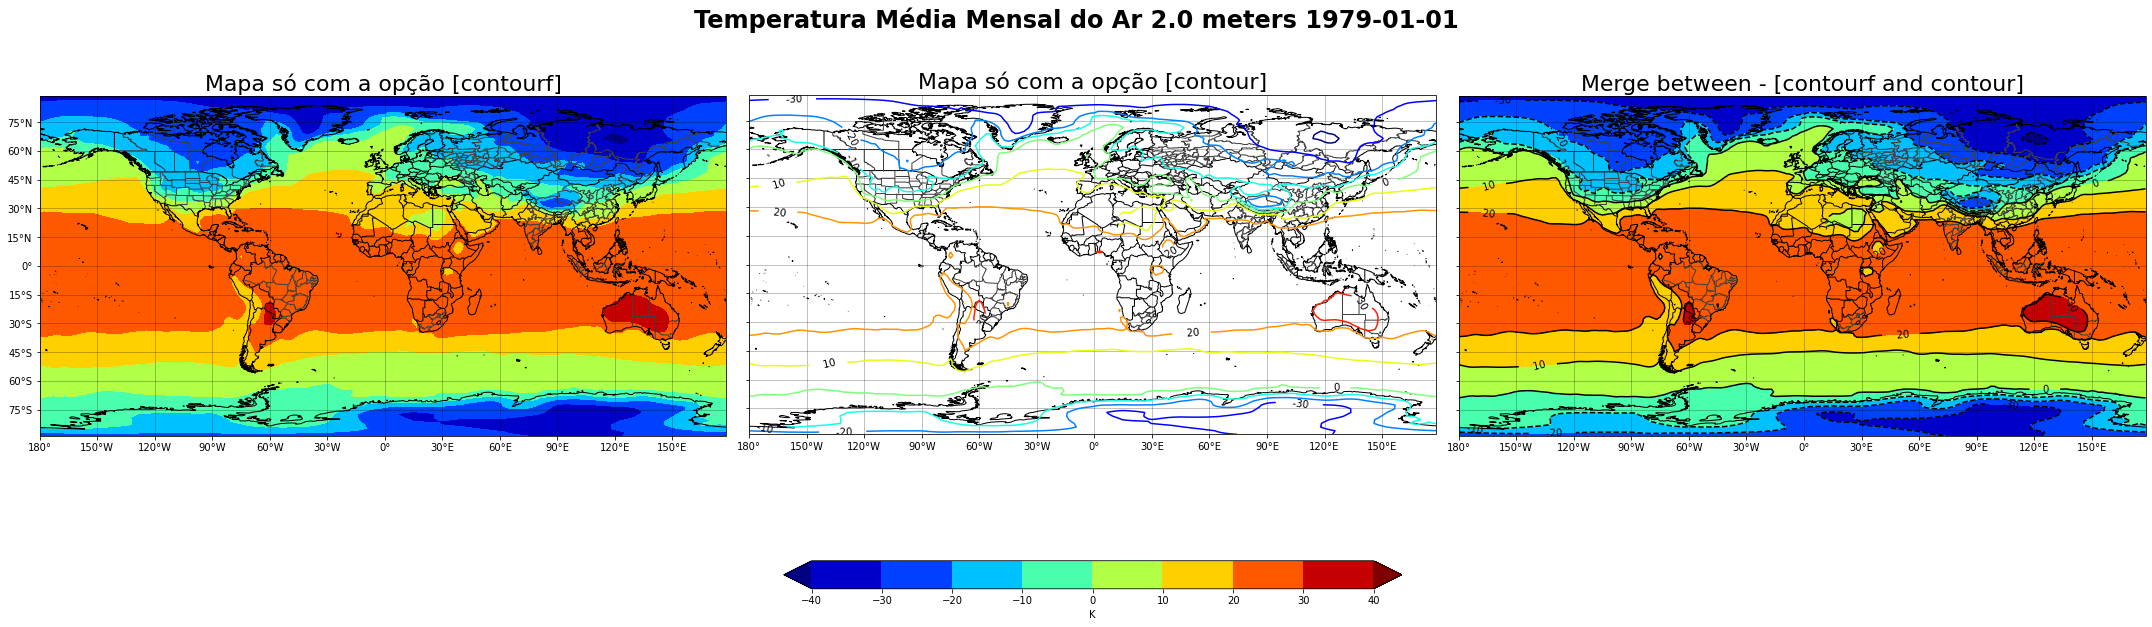

In [ ]:
# CRIANDO A FIGURA E FORMATANDO O PLOT COM O PACOTE CARTOPY
# FAZENDO AS DIFERENÇAS ENTRE CONTOURF E CONTOUR
print("10. Criando a figura")

# Criando e ajustando o tamanho da figura
# Agregando a projeção cartográfica <- PlateCarree() <- Projeção cilíndrica equidistante
print("11. Criando a figura e estabelecen 3 plots")
fig, ax = plt.subplots(1,3, figsize=(30,12),subplot_kw={'projection': ccrs.PlateCarree()}, sharey=True)

# Criando um array para formatar os límites dos eixos X e Y
print("12. Agregando arrays para formatas os eixos")
xticks = np.arange(-180,240,30)
yticks = np.arange(-90,105,15)

#--------------------------------------------------------------------------------------------------------------------------

# CRIANDO O MAPA 1 - COM CONTOURF
print("13. Criando o plot 1")
# FORMATANDO O PLOT COM AS FUNÇÕES DO CARTOPY
# Formatando os límites do eixo X <- Longitude
print("14. Opção de formatação dos eixos")
ax[0].set_xticks(xticks, crs=ccrs.PlateCarree()) 
# Formatando os límites do eixo Y <- Latitude
ax[0].set_yticks(yticks, crs=ccrs.PlateCarree())
# Fazenddo o eixo X no formato de Latitude ºW
ax[0].xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS
ax[0].yaxis.set_major_formatter(LatitudeFormatter())

# AGREGANDO LINHAS DE COSTA, LÍMITES DOS PAISES E ESTADOS DO BRASIL
# Agregando linhas de costa com resolução de 50m
print("15. Agregando linhas de costa, límites dos paises e os estados")
ax[0].coastlines('50m')
# Agregando os límites dos paises
ax[0].add_feature(cfeature.BORDERS)
# Agregando os estados do Brasil ()mas também agrega os estados de The USA)
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
ax[0].add_feature(states_provinces, edgecolor='0.25')
# Agregando linhas de grade
ax[0].grid(c='k', ls='-', alpha=0.3)

# Criando um array para a paleta de cores
print("16. Estabelecendo os rango de valores da paleta de cores")
colorb=np.arange(-40,50,10)

# Criando um gráfico com o formato de contornos
print("17. Criando o gráfico com a opção contourf")
cf = ax[0].contourf(ds.lon, ds.lat, ds['air'].isel(time=0, level=0), levels=colorb, extend='both', cmap='jet')

# Agregar título para o plot
print("18. Agregando título ao plot 1")
ax[0].set_title('Mapa só com a opção [contourf]', size = 22)

# -------------------------------------------------------------------------------------------------------------

# CRIANDO O MAPA 2 - CONTOUR

# FORMATANDO O PLOT COM AS FUNÇÕES DO CARTOPY
# Formatando os límites do eixo X <- Longitude
ax[1].set_xticks(xticks, crs=ccrs.PlateCarree()) 
# Formatando os límites do eixo Y <- Latitude
ax[1].set_yticks(yticks, crs=ccrs.PlateCarree())
# Fazenddo o eixo X no formato de Latitude ºW
ax[1].xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS
ax[1].yaxis.set_major_formatter(LatitudeFormatter())

# AGREGANDO LINHAS DE COSTA, LÍMITES DOS PAISES E ESTADOS DO BRASIL
# Agregando linhas de costa com resolução de 50m
ax[1].coastlines('50m')
# Agregando os límites dos paises
ax[1].add_feature(cfeature.BORDERS)
# Agregando os estados do Brasil ()mas também agrega os estados de The USA)
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
ax[1].add_feature(states_provinces, edgecolor='0.25')
# Agregando linhas de grade
ax[1].grid(c='k', ls='-', alpha=0.3)

# Criando um array para a paleta de cores
colorb=np.arange(-40,50,10)

# Criando um gráfico com o formato de contornos
print("19. Criando o gráfico com a opção contour")
c = ax[1].contour(ds.lon, ds.lat, ds['air'].isel(time=0, level=0), levels=colorb, extend='both', cmap='jet')

# Agregando os labels às linhas de contour
print("*. Agregando valores aos contornos")
ax[1].clabel(
    c,                        # Agregamos a variável com os contornos
    colors = ['black'],       # Cor dos labels dos valores dos contornos
    manual = False,           # Pôr os labels de forma automática frente à forma manual
    inline = True,            # Valores dentro da linha <- ----15------
    fmt = ' {:.0f}'.format,   # Labels como valores inteiros
    )

# Agregar título para o plot
print("20. Agregando título ao plot 2")
ax[1].set_title('Mapa só com a opção [contour]', size = 22)

# -------------------------------------------------------------------------------------------------------------

# CRIANDO O MAPA 3 - JUNTANDO CONTOURF E CONTOUR

# FORMATANDO O PLOT COM AS FUNÇÕES DO CARTOPY
# Formatando os límites do eixo X <- Longitude
ax[2].set_xticks(xticks, crs=ccrs.PlateCarree()) 
# Formatando os límites do eixo Y <- Latitude
ax[2].set_yticks(yticks, crs=ccrs.PlateCarree())
# Fazenddo o eixo X no formato de Latitude ºW
ax[2].xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS
ax[2].yaxis.set_major_formatter(LatitudeFormatter())

# AGREGANDO LINHAS DE COSTA, LÍMITES DOS PAISES E ESTADOS DO BRASIL
# Agregando linhas de costa com resolução de 50m
ax[2].coastlines('50m')
# Agregando os límites dos paises
ax[2].add_feature(cfeature.BORDERS)
# Agregando os estados do Brasil ()mas também agrega os estados de The USA)
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
ax[2].add_feature(states_provinces, edgecolor='0.25')
# Agregando linhas de grade
ax[2].grid(c='k', ls='-', alpha=0.3)

# Criando um array para a paleta de cores
colorb=np.arange(-40,50,10)

# Criando um gráfico com o formato de contornos
print("21. Fazendo um merge das opções contourf e contour")

print("22. Agrendo contourf")
cf = ax[2].contourf(ds.lon, ds.lat, ds['air'].isel(time=0, level=0), levels=colorb, extend='both', cmap='jet')
print("23. Agregando contour")
cb = ax[2].contour(ds.lon, ds.lat, ds['air'].isel(time=0, level=0), levels = colorb, colors = ['black'])

# Agregando os labels às linhas de contour
ax[2].clabel(
    cb,                        # Agregamos a variável com os contornos
    colors = ['black'],       # Cor dos labels dos valores dos contornos
    manual = False,           # Pôr os labels de forma automática frente à forma manual
    inline = True,            # Valores dentro da linha <- ----15------
    fmt = ' {:.0f}'.format,   # Labels como valores inteiros
    )

# Agregar título para o plot
print("24. Agregando título ao plot 3")
ax[2].set_title('Merge between - [contourf and contour]', size = 22)

# ---------------------------------------------------------------------------------------------------------------------------

# Paleta de cores no médio da figura
print("25. Agregando paleta de cores no médio da figura")
cbar = plt.colorbar(cf,ticks = colorb, label='K', orientation = 'horizontal', shrink = 0.9, ax=ax[1]) 

# Agregando Título à figura
print("26. Agregando supertile à figura")
plt.suptitle('Temperatura Média Mensal do Ar 2.0 meters 1979-01-01', y = 0.8, size = 24, fontweight='bold', fontfamily='sans')

# Ordenando o espaçamento
print("27. Formatando os espaçõs entre os plots e títulos")
plt.subplots_adjust(hspace = 1, top = 1)

# Menos espaços em branco
fig.tight_layout()

# Salvando a figura
print("28. Salavando a figura .png")
fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_01/contour_contourf_mergecontours.png', format='png', dpi = 100)

print("29. Figura salvada")

# **Trablhando com os campos de MSLP e Vento**

Abrindo os arquivos NetCDF de nosso drive com os dados do MSLP

Ler o dataset NetCDF - mslp.mon.mean.nc
1. Ler o dataset NetCDF - mslp.mon.mean.nc
2. Ver a informação/descrição do file NetCDF
<xarray.Dataset>
Dimensions:    (lat: 73, lon: 144, nbnds: 2, time: 518)
Coordinates:
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] ...
    mslp       (time, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.

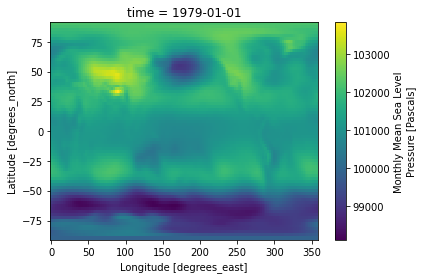

In [42]:
# ABRINDO O ARQUIVO NETCDF QUE ESTA EM NOSSO DRIVE COM OS DADOS DE MSLP

# Dataset pressão reduzida ao nível méio do mar - média mensal
print("Ler o dataset NetCDF - mslp.mon.mean.nc")
ds_mslp =  xr.open_dataset('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/dados/NCEP-NOAA/mslp.mon.mean.nc')

# Dataset pressão reduzida ao nível méio do mar - média mensal
print("1. Ler o dataset NetCDF - mslp.mon.mean.nc")
ds_mslp['mslp'].sel(time='1979-01-01').plot()

# Olhando a informação/descrição do file NetCDF
print("2. Ver a informação/descrição do file NetCDF")
print(ds_mslp)

Fazendo a conversão de unidades da pressão reduzida ao nível médio do mar para todos as dimensões 

- Conversão de Pascals (Pa) para Hectopascals (hPa)

3. Fazendo um plot rápido do mslp


<xarray.Dataset>
Dimensions:    (lat: 73, lon: 144, nbnds: 2, time: 518)
Coordinates:
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] ...
    mslp       (time, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

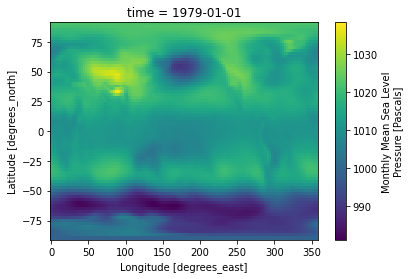

In [43]:
# Fazendo a conversão de Pascals (Pa) para Hectopascals (hPa)
ds_mslp['mslp'][:,:,:] = ds_mslp['mslp'][:,:,:]/100

# Fazer um plot para visualizar a conversão das unidades de pressão
print("3. Fazendo um plot rápido do mslp")
ds_mslp['mslp'].sel(time='1979-01-01').plot()

# Ver a descrição do arquivo
ds_mslp

Fazer a transformação do formato das longitudes. Trocar do formato de 0º - 360º para o formato de -180º a +180º

In [44]:
# Fazendo a conversão das longitudes no formato de -180º até +180º

# MSLP
# Fazendo a transformação do formato das longitudes de 0 a 360º para -180º a +180º
print("4. Tranformação do formato das longitudes - mslp")
ds_mslp.coords['lon'] = (ds_mslp.coords['lon']+180) % 360 - 180
# Ordenando o dataset baseado no novo formato da longitude -180º a +180º
# Lembrar da função <- ".sortby()"
print("5. Ordenando o dataset baseado no novo formato da longitude -180º a 180º")
ds_mslp = ds_mslp.sortby(ds_mslp.lon)

# Olhando a informação/descrição do file NetCDF
print("6. Ver a informação/descrição do file NetCDF")
print(ds_mslp)

4. Tranformação do formato das longitudes - mslp
5. Ordenando o dataset baseado no novo formato da longitude -180º a 180º
6. Ver a informação/descrição do file NetCDF
<xarray.Dataset>
Dimensions:    (lat: 73, lon: 144, nbnds: 2, time: 518)
Coordinates:
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-03-01
    mslp       (time, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dat

Criar o mapa utilizando o pacote "cartopy"

*. Criando a figura
*. Criando a figura e estabelecen 3 plots
*. Agregando arrays para formatas os eixos
7. Criando o plot 1
8. Opção de formatação dos eixos
9. Agregando linhas de costa, límites dos paises e os estados
10. Estabelecendo os rango de valores da paleta de cores
11. Agrendo contourf
12. Agregando contour
13. Agregando título ao plot 1
14. Formatando os espaçõs entre os plots e títulos
15. Salavando a figura .png
16. Figura salvada


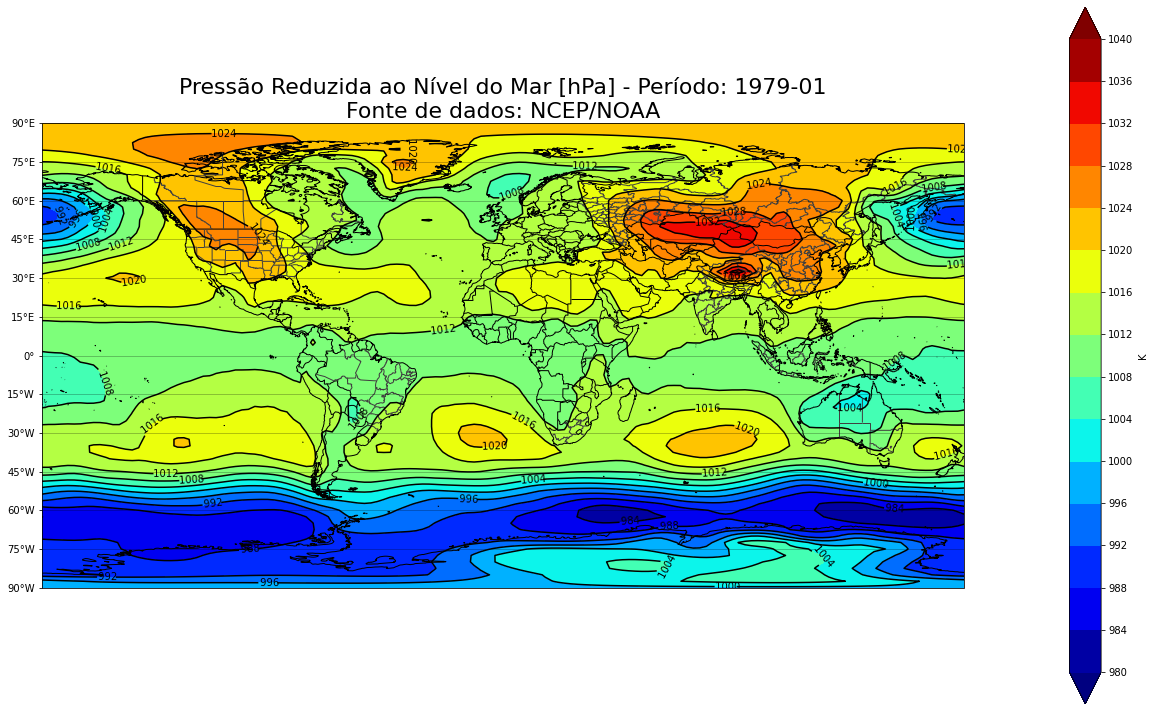

In [45]:
# CRIANDO A FIGURA E FORMATANDO O PLOT COM O PACOTE CARTOPY

print("*. Criando a figura")

# Criando e ajustando o tamanho da figura
# Agregando a projeção cartográfica <- PlateCarree() <- Projeção cilíndrica equidistante
print("*. Criando a figura e estabelecen 3 plots")
# Nesta seção vamos criar só dois plots n_rows =1, n_cols=1
fig, ax = plt.subplots(figsize=(30,12),subplot_kw={'projection': ccrs.PlateCarree()}, sharey=True)

# Criando um array para formatar os límites dos eixos X e Y
print("*. Agregando arrays para formatas os eixos")
# Lembrar de utilizar o pacote Numpy como <- np.arange
xticks = np.arange(-180,240,30)
yticks = np.arange(-90,105,15)

#--------------------------------------------------------------------------------------------------------------------------

# CRIANDO O MAPA 1 - MSLP
print("7. Criando o plot 1")
# FORMATANDO O PLOT COM AS FUNÇÕES DO CARTOPY
# Formatando os límites do eixo X <- Longitude <- .set_xticks()
print("8. Opção de formatação dos eixos")
ax.set_yticks(yticks, crs=ccrs.PlateCarree()) 
# Formatando os límites do eixo Y <- Latitude <- set_yticks()
ax.set_yticks(yticks, crs=ccrs.PlateCarree()) 
# Fazenddo o eixo X no formato de Latitude ºW <- .xaxis.set_major_formatter()
ax.xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS <- .yaxis.set_major_formatter()
ax.yaxis.set_major_formatter(LongitudeFormatter())

# AGREGANDO LINHAS DE COSTA, LÍMITES DOS PAISES E ESTADOS DO BRASIL
# Agregando linhas de costa com resolução de 50m <- .coastlines()
print("9. Agregando linhas de costa, límites dos paises e os estados")
ax.coastlines('50m')
# Agregando os límites dos paises <- .add_feature()
ax.add_feature(cfeature.BORDERS)
# Agregando os estados do Brasil (mas também agrega os ecb = ax.set_title('Mapa só com a opção [contourf]', size = 22)
# Lembrar da função <- .cfeature.NaturalEarthFeature()
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
# Agregar os estados do Brasil No primer plot <- .add_feature()
ax.add_feature(states_provinces, edgecolor='0.25')
# Agregando linhas de grade <- .grid()
ax.grid(c='k', ls='-', alpha=0.3)

# Criando um array para a paleta de cores
print("10. Estabelecendo os rango de valores da paleta de cores")
# Lembrar do pacote Numpy, o rango de valores para a mslp [980, 1044, 4] <- np.arange()
colorb = np.arange(980,1044,4)

# Criando um gráfico com o formato de contornos
# Lembrar da função <- .contourf(lon, lat, data, levels, extend, cmap)
print("11. Agrendo contourf")
cf = ax.contourf(ds_mslp.lon, ds_mslp.lat, ds_mslp['mslp'].isel(time=0), levels=colorb, extend='both', cmap='jet')
print("12. Agregando contour")
# Lembrar da função <- .contour(lon, lat, data, levels, colors=['black'])
cb = ax.contour(ds_mslp.lon, ds_mslp.lat, ds_mslp['mslp'].isel(time=0), levels = colorb, colors = ['black'])

# Agregando os labels às linhas de contour
ax.clabel(
    cb,                        # Agregamos a variável com os contornos
    colors = ['black'],       # Cor dos labels dos valores dos contornos
    manual = False,           # Pôr os labels de forma automática frente à forma manual
    inline = True,            # Valores dentro da linha <- ----15------
    fmt = ' {:.0f}'.format,   # Labels como valores inteiros
    )

# Agregar título para o plot
print("13. Agregando título ao plot 1")
ax.set_title('Pressão Reduzida ao Nível do Mar [hPa] - Período: 1979-01\nFonte de dados: NCEP/NOAA', size = 22)

cbar = plt.colorbar(cf,ticks = colorb, label='K', orientation = 'vertical', shrink = 1.5, ax=ax) 
# ---------------------------------------------------------------------------------------------------------------------------

# Ordenando o espaçamento
print("14. Formatando os espaçõs entre os plots e títulos")
plt.subplots_adjust(hspace = 1, top = 1)

# Menos espaços em branco
fig.tight_layout()

# Salvando a figura
print("15. Salavando a figura .png")
fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_01/mslp.png', format='png', dpi = 100)

print("16. Figura salvada")

**Trabalhando com os campos de U e V**

- u: componente zonal do vento
- v: componente meridional do vento

Ler os dados do vento meridional e vento zonal

In [ ]:
# ABRINDO O ARQUIVO NETCDF QUE ESTA EM NOSSO DRIVE COM OS DADOS DE UWND E VWND
# Dataset componente zonal do vento - média mensal
print("1. Ler o dataset NetCDF - u")
ds_u = xr.open_dataset('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/dados/NCEP-NOAA/uwnd.mon.mean.nc')

# Dataset componente meridional do vento - média mensal
print("2. Ler o dataset NetCDF - v")
ds_v = xr.open_dataset('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/dados/NCEP-NOAA/vwnd.mon.mean.nc')

# Olhando a informação/descrição do file NetCDF
print("3. Ver a informação/descrição do file NetCDF")
print(ds_u)
print("# ---------------------------------------------------------------------------------------------------")
ds_v

1. Ler o dataset NetCDF - u
2. Ler o dataset NetCDF - v
3. Ver a informação/descrição do file NetCDF
<xarray.Dataset>
Dimensions:    (lat: 73, level: 17, lon: 144, nbnds: 2, time: 518)
Coordinates:
  * level      (level) float32 1e+03 925.0 850.0 700.0 ... 50.0 30.0 20.0 10.0
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] ...
    uwnd       (time, level, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    datase

<xarray.Dataset>
Dimensions:    (lat: 73, level: 17, lon: 144, nbnds: 2, time: 518)
Coordinates:
  * level      (level) float32 1e+03 925.0 850.0 700.0 ... 50.0 30.0 20.0 10.0
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] ...
    vwnd       (time, level, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

Fazer um plot rápido da componente zonal do vento

4. Fazendo um plot rápido do u


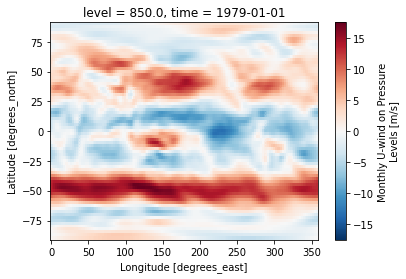

In [ ]:
# Fazendo um plot para dar uma olhada geral dos dados utilizando a opção:
# sel <- selection
# seleccionar a data no formato de string, em nosso caso vai ser 'YYYY-MM-DD'
print("4. Fazendo um plot rápido do u")
# Convertendo a escalada de Pa --> hPa
ds_u['uwnd'].sel(time='1979-01', level=850).plot()

Fazer um plot da componente meridional do vento

5. Fazendo um plot rápido do v


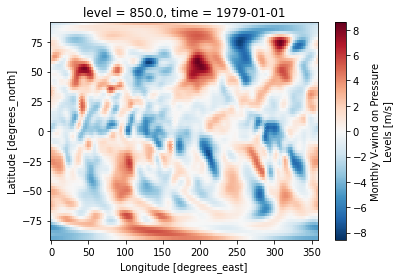

In [ ]:
# Fazendo um plot para dar uma olhada geral dos dados utilizando a opção:
# sel <- selection
# seleccionar a data no formato de string, em nosso caso vai ser 'YYYY-MM-DD'
print("5. Fazendo um plot rápido do v")
# Convertendo a escalada de Pa --> hPa
ds_v['vwnd'].sel(time='1979-01', level=850).plot()

Fazer a transformação do formato das longitudes: De 0º - 360º para o formato de -180º até +180º

In [ ]:
# Fazendo a conversão das longitudes no formato de -180º até +180º

# U
# Fazendo a transformação do formato das longitudes de 0 a 360º para -180º a +180º
print("6. Tranformação do formato das longitudes - u")
ds_u.coords['lon'] = (ds_u.coords['lon'] + 180) % 360 - 180
# Ordenando o dataset baseado no novo formato da longitude -180º a +180º
print("7. Ordenando o dataset baseado no novo formato da longitude -180º a 180º")
ds_u = ds_u.sortby(ds_u.lon)

# --------------------------------------------------------------------------------------------

# V
# Fazendo a transformação do formato das longitudes de 0 a 360º para -180º a +180º
print("8. Tranformação do formato das longitudes - v")
ds_v.coords['lon'] = (ds_v.coords['lon'] + 180) % 360 - 180
# Ordenando o dataset baseado no novo formato da longitude -180º a +180º
print("9. Ordenando o dataset baseado no novo formato da longitude -180º a 180º")
ds_v = ds_v.sortby(ds_v.lon)

# Olhando a informação/descrição do file NetCDF
print("10. Ver a informação/descrição do file NetCDF")
print(ds_u)
print("# ---------------------------------------------------------------------------------------------------")
ds_v

6. Tranformação do formato das longitudes - u
7. Ordenando o dataset baseado no novo formato da longitude -180º a 180º
8. Tranformação do formato das longitudes - v
9. Ordenando o dataset baseado no novo formato da longitude -180º a 180º
10. Ver a informação/descrição do file NetCDF
<xarray.Dataset>
Dimensions:    (lat: 73, level: 17, lon: 144, nbnds: 2, time: 518)
Coordinates:
  * level      (level) float32 1e+03 925.0 850.0 700.0 ... 50.0 30.0 20.0 10.0
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] ...
    uwnd       (time, level, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Rean

<xarray.Dataset>
Dimensions:    (lat: 73, level: 17, lon: 144, nbnds: 2, time: 518)
Coordinates:
  * level      (level) float32 1e+03 925.0 850.0 700.0 ... 50.0 30.0 20.0 10.0
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-03-01
    vwnd       (time, level, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

Calcular o modulo do vetor velocidade

11. Criando a variável da velocidade do vento


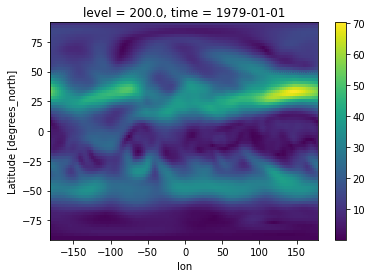

In [ ]:
# Criando a variável da velocidade do vento - wspd
print("11. Criando a variável da velocidade do vento")
wspd = (ds_u['uwnd']**2 + ds_v['vwnd']**2)**0.5

# Fazendo um plot
wspd.sel(time='1979-01', level = 200).plot()

Fazer o mapa com a velocidade do vento e linhas de corrente

12. Criando a figura
*. Criando a figura e estabelecen 3 plots
*. Agregando arrays para formatas os eixos
13. Criando o plot 1
14. Opção de formatação dos eixos
15. Agregando linhas de costa, límites dos paises e os estados
16. Estabelecendo os rango de valores da paleta de cores
17. Agrendo contourf
18. Agregando linhas de corrente
19. Agregando título ao plot 1
20. Formatando os espaçõs entre os plots e títulos
21. Salavando a figura .png
22. Figura salvada


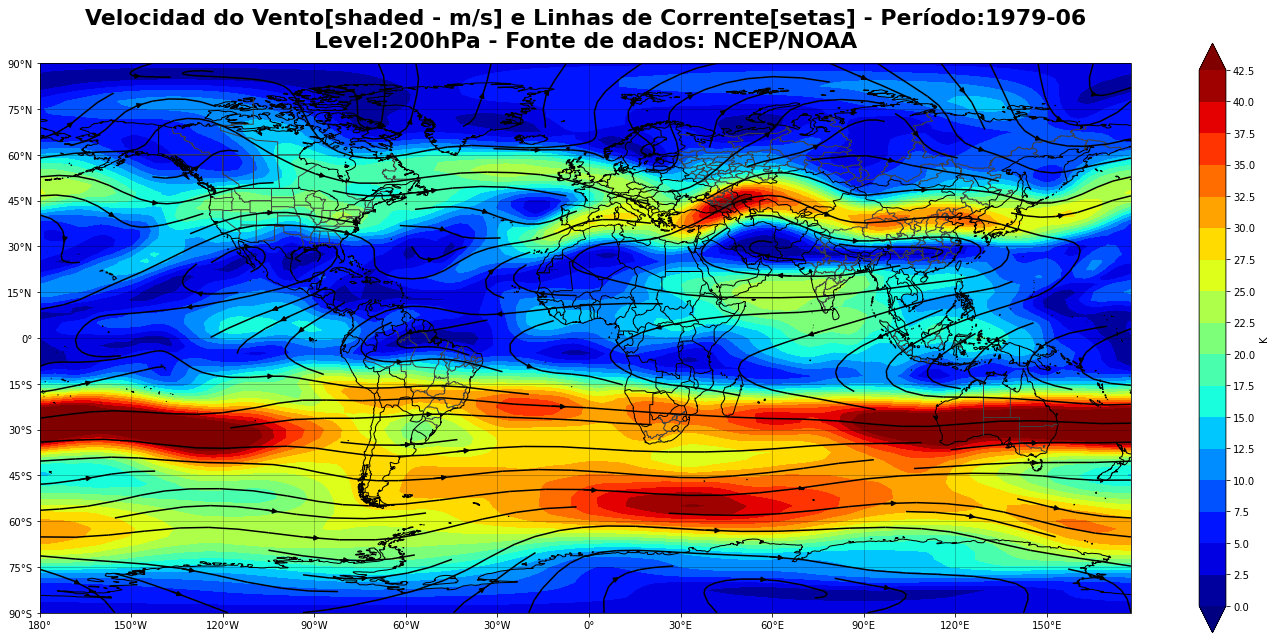

In [ ]:
# CRIANDO A FIGURA E FORMATANDO O PLOT COM O PACOTE CARTOPY

print("12. Criando a figura")

# Criando e ajustando o tamanho da figura
# Agregando a projeção cartográfica <- PlateCarree() <- Projeção cilíndrica equidistante
print("*. Criando a figura e estabelecen 3 plots")
fig, ax = plt.subplots(figsize=(20,12),subplot_kw={'projection': ccrs.PlateCarree()}, sharey=True)

# Criando um array para formatar os límites dos eixos X e Y
print("*. Agregando arrays para formatas os eixos")
xticks = np.arange(-180,240,30)
yticks = np.arange(-90,105,15)

#--------------------------------------------------------------------------------------------------------------------------

# CRIANDO O MAPA 1 - MSLP
print("13. Criando o plot 1")
# FORMATANDO O PLOT COM AS FUNÇÕES DO CARTOPY
# Formatando os límites do eixo X <- Longitude
print("14. Opção de formatação dos eixos")
ax.set_xticks(xticks, crs=ccrs.PlateCarree()) 
# Formatando os límites do eixo Y <- Latitude
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
# Fazenddo o eixo X no formato de Latitude ºW
ax.xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS
ax.yaxis.set_major_formatter(LatitudeFormatter())

# AGREGANDO LINHAS DE COSTA, LÍMITES DOS PAISES E ESTADOS DO BRASIL
# Agregando linhas de costa com resolução de 50m
print("15. Agregando linhas de costa, límites dos paises e os estados")
ax.coastlines('50m')
# Agregando os límites dos paises
ax.add_feature(cfeature.BORDERS)
# Agregando os estados do Brasil ()mas também agrega os estados de The USA)
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
ax.add_feature(states_provinces, edgecolor='0.25')
# Agregando linhas de grade
ax.grid(c='k', ls='-', alpha=0.3)

# Criando um array para a paleta de cores
print("16. Estabelecendo os rango de valores da paleta de cores")
colorb = np.arange(0,45,2.5)

# Criando um gráfico com o formato de contornos
print("17. Agrendo contourf")
cf = ax.contourf(wspd.lon, wspd.lat, wspd.isel(time=6, level=9), levels=colorb, extend='both', cmap='jet', transform=ccrs.PlateCarree())
print("18. Agregando linhas de corrente")
strm = ax.streamplot(wspd.lon, wspd.lat, ds_u['uwnd'].isel(time=6, level=9).values, ds_v['vwnd'].isel(time=6, level=9).values,\
                     color='black', transform = ccrs.PlateCarree())

# Agregar título para o plot
print("19. Agregando título ao plot 1")
ax.set_title('Velocidad do Vento[shaded - m/s] e Linhas de Corrente[setas] - Período:1979-06\nLevel:200hPa - Fonte de dados: NCEP/NOAA',\
             size = 22, fontweight='bold', fontfamily='sans', y=1.02)

cbar = plt.colorbar(cf,ticks = colorb, label='K', orientation = 'vertical', shrink = 0.7, ax=ax)  

# ---------------------------------------------------------------------------------------------------------------------------

# Ordenando o espaçamento
print("20. Formatando os espaçõs entre os plots e títulos")
plt.subplots_adjust(hspace = 1, top = 1)

# Menos espaços em branco
fig.tight_layout()

# Salvando a figura
print("21. Salavando a figura .png")
fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_01/linhas_corrente_200.png', format='png', dpi = 100)

print("22. Figura salvada")

Fazer o plot com a velocidade do vento e vetores do vento

*. Criando a figura
*. Criando a figura e estabelecen 3 plots
*. Agregando arrays para formatas os eixos
13. Criando o plot 1
14. Opção de formatação dos eixos
15. Agregando linhas de costa, límites dos paises e os estados
16. Estabelecendo os rango de valores da paleta de cores
17. Agrendo contourf
18. Agregando linhas de corrente
*. Agregando vetores do vento
19. Agregando título ao plot 1
20. Formatando os espaçõs entre os plots e títulos
21. Salavando a figura .png
22. Figura salvada


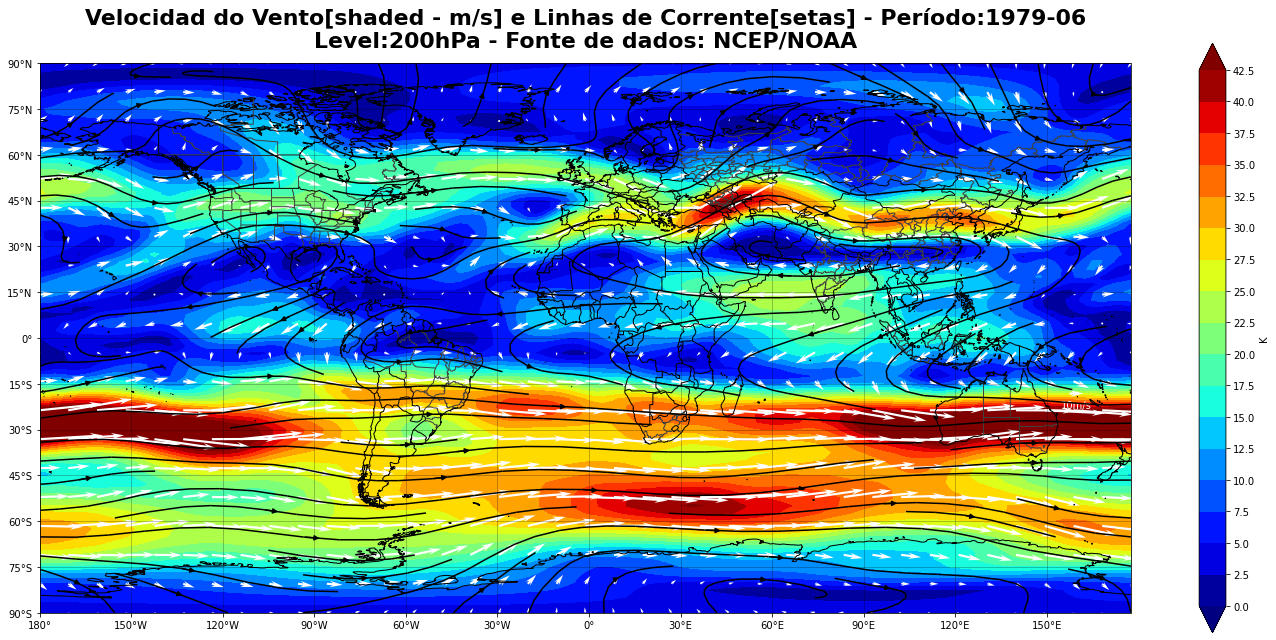

In [ ]:
# CRIANDO A FIGURA E FORMATANDO O PLOT COM O PACOTE CARTOPY

print("*. Criando a figura")

# Criando e ajustando o tamanho da figura
# Agregando a projeção cartográfica <- PlateCarree() <- Projeção cilíndrica equidistante
print("*. Criando a figura e estabelecen 3 plots")
fig, ax = plt.subplots(figsize=(20,12),subplot_kw={'projection': ccrs.PlateCarree()}, sharey=True)

# Criando um array para formatar os límites dos eixos X e Y
print("*. Agregando arrays para formatas os eixos")
xticks = np.arange(-180,240,30)
yticks = np.arange(-90,105,15)

#--------------------------------------------------------------------------------------------------------------------------

# CRIANDO O MAPA 1 - MSLP
print("13. Criando o plot 1")
# FORMATANDO O PLOT COM AS FUNÇÕES DO CARTOPY
# Formatando os límites do eixo X <- Longitude
print("14. Opção de formatação dos eixos")
ax.set_xticks(xticks, crs=ccrs.PlateCarree()) 
# Formatando os límites do eixo Y <- Latitude
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
# Fazenddo o eixo X no formato de Latitude ºW
ax.xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS
ax.yaxis.set_major_formatter(LatitudeFormatter())

# AGREGANDO LINHAS DE COSTA, LÍMITES DOS PAISES E ESTADOS DO BRASIL
# Agregando linhas de costa com resolução de 50m
print("15. Agregando linhas de costa, límites dos paises e os estados")
ax.coastlines('50m')
# Agregando os límites dos paises
ax.add_feature(cfeature.BORDERS)
# Agregando os estados do Brasil ()mas também agrega os estados de The USA)
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
ax.add_feature(states_provinces, edgecolor='0.25')
# Agregando linhas de grade
ax.grid(c='k', ls='-', alpha=0.3)

# Criando um array para a paleta de cores
print("16. Estabelecendo os rango de valores da paleta de cores")
colorb = np.arange(0,45,2.5)

# Criando um gráfico com o formato de contornos
print("17. Agrendo contourf")
cf = ax.contourf(wspd.lon, wspd.lat, wspd.isel(time=6, level=9), levels=colorb, extend='both', cmap='jet', transform=ccrs.PlateCarree())
print("18. Agregando linhas de corrente")
strm = ax.streamplot(wspd.lon, wspd.lat, ds_u['uwnd'].isel(time=6, level=9).values, ds_v['vwnd'].isel(time=6, level=9).values,\
                     color='black', transform = ccrs.PlateCarree())

# Criando os vetores do vento
print("*. Agregando vetores do vento")
vetor = ax.quiver(wspd.lon, wspd.lat, ds_u['uwnd'].isel(time=6, level=9).values, ds_v['vwnd'].isel(time=6, level=9).values,\
                  width=0.002, regrid_shape=20, color='white', headlength=6, transform=ccrs.PlateCarree())

ax.quiverkey(vetor,                     #Incoming quiver handle
             X=0.95, Y = 0.4,       #Determine the location of label, all limited to [0,1]
             U = 10,                    #Reference arrow length means the wind speed is 5m/s.
             angle = 0,            #Reference arrow placement angle. The default is 0, which means horizontal placement
             label='10m/s',        #Arrow's supplement: label's content + 
             labelpos='S',          #label is in which direction of the reference arrow; S means south
             color = 'white',labelcolor = 'white', #Arrow color + label color
             )

# Fazendo plot dos vetores no mesmo tamanho
#r = np.power(np.add(np.power(ds_u['uwnd'].isel(time=6, level=9).values, 2), np.power(ds_v['vwnd'].isel(time=6, level=9).values, 2)), 0.5) 
#ax.quiver(wspd.lon, wspd.lat, ds_u['uwnd'].isel(time=6, level=9).values/r, ds_v['vwnd'].isel(time=6, level=9).values/r,\
#          regrid_shape=20, color='white', transform=ccrs.PlateCarree())


# Agregar título para o plot
print("19. Agregando título ao plot 1")
ax.set_title('Velocidad do Vento[shaded - m/s] e Linhas de Corrente[setas] - Período:1979-06\nLevel:200hPa - Fonte de dados: NCEP/NOAA',\
             size = 22, fontweight='bold', fontfamily='sans', y=1.02)

cbar = plt.colorbar(cf,ticks = colorb, label='K', orientation = 'vertical', shrink = 0.7, ax=ax)  

# ---------------------------------------------------------------------------------------------------------------------------

# Ordenando o espaçamento
print("20. Formatando os espaçõs entre os plots e títulos")
plt.subplots_adjust(hspace = 1, top = 1)

# Menos espaços em branco
fig.tight_layout()

# Salvando a figura
print("21. Salavando a figura .png")
#fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_01/linhas_corrente_200.png', format='png', dpi = 100)

print("22. Figura salvada")

Fazer o plot da velocidade do vento e normalizar a maginitude dos vetores vento

*. Criando a figura
*. Criando a figura e estabelecen 3 plots
*. Agregando arrays para formatas os eixos
13. Criando o plot 1
14. Opção de formatação dos eixos
15. Agregando linhas de costa, límites dos paises e os estados
16. Estabelecendo os rango de valores da paleta de cores
17. Agrendo contourf
18. Agregando linhas de corrente
*. Agregando vetores do vento
19. Agregando título ao plot 1
20. Formatando os espaçõs entre os plots e títulos
21. Salavando a figura .png
22. Figura salvada


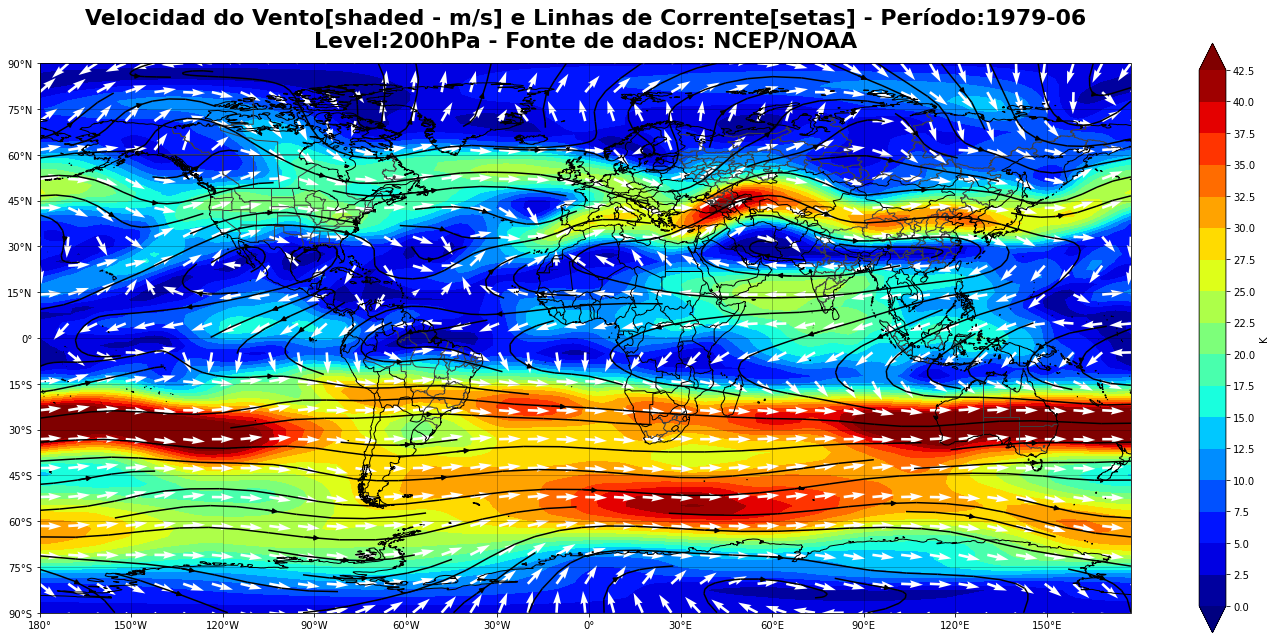

In [ ]:
# CRIANDO A FIGURA E FORMATANDO O PLOT COM O PACOTE CARTOPY

print("*. Criando a figura")

# Criando e ajustando o tamanho da figura
# Agregando a projeção cartográfica <- PlateCarree() <- Projeção cilíndrica equidistante
print("*. Criando a figura e estabelecen 3 plots")
fig, ax = plt.subplots(figsize=(20,12),subplot_kw={'projection': ccrs.PlateCarree()}, sharey=True)

# Criando um array para formatar os límites dos eixos X e Y
print("*. Agregando arrays para formatas os eixos")
xticks = np.arange(-180,240,30)
yticks = np.arange(-90,105,15)

#--------------------------------------------------------------------------------------------------------------------------

# CRIANDO O MAPA 1 - MSLP
print("13. Criando o plot 1")
# FORMATANDO O PLOT COM AS FUNÇÕES DO CARTOPY
# Formatando os límites do eixo X <- Longitude
print("14. Opção de formatação dos eixos")
ax.set_xticks(xticks, crs=ccrs.PlateCarree()) 
# Formatando os límites do eixo Y <- Latitude
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
# Fazenddo o eixo X no formato de Latitude ºW
ax.xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS
ax.yaxis.set_major_formatter(LatitudeFormatter())

# AGREGANDO LINHAS DE COSTA, LÍMITES DOS PAISES E ESTADOS DO BRASIL
# Agregando linhas de costa com resolução de 50m
print("15. Agregando linhas de costa, límites dos paises e os estados")
ax.coastlines('50m')
# Agregando os límites dos paises
ax.add_feature(cfeature.BORDERS)
# Agregando os estados do Brasil ()mas também agrega os estados de The USA)
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
ax.add_feature(states_provinces, edgecolor='0.25')
# Agregando linhas de grade
ax.grid(c='k', ls='-', alpha=0.3)

# Criando um array para a paleta de cores
print("16. Estabelecendo os rango de valores da paleta de cores")
colorb = np.arange(0,45,2.5)

# Criando um gráfico com o formato de contornos
print("17. Agrendo contourf")
cf = ax.contourf(wspd.lon, wspd.lat, wspd.isel(time=6, level=9), levels=colorb, extend='both', cmap='jet', transform=ccrs.PlateCarree())
print("18. Agregando linhas de corrente")
strm = ax.streamplot(wspd.lon, wspd.lat, ds_u['uwnd'].isel(time=6, level=9).values, ds_v['vwnd'].isel(time=6, level=9).values,\
                     color='black', transform = ccrs.PlateCarree())

# Criando os vetores do vento
print("*. Agregando vetores do vento")

# Fazendo plot dos vetores no mesmo tamanho
r = np.power(np.add(np.power(ds_u['uwnd'].isel(time=6, level=9).values, 2), np.power(ds_v['vwnd'].isel(time=6, level=9).values, 2)), 0.5) 
ax.quiver(wspd.lon, wspd.lat, ds_u['uwnd'].isel(time=6, level=9).values/r, ds_v['vwnd'].isel(time=6, level=9).values/r,\
          regrid_shape=20, color='white', transform=ccrs.PlateCarree())


# Agregar título para o plot
print("19. Agregando título ao plot 1")
ax.set_title('Velocidad do Vento[shaded - m/s] e Linhas de Corrente[setas] - Período:1979-06\nLevel:200hPa - Fonte de dados: NCEP/NOAA',\
             size = 22, fontweight='bold', fontfamily='sans', y=1.02)

cbar = plt.colorbar(cf,ticks = colorb, label='K', orientation = 'vertical', shrink = 0.7, ax=ax)  

# ---------------------------------------------------------------------------------------------------------------------------

# Ordenando o espaçamento
print("20. Formatando os espaçõs entre os plots e títulos")
plt.subplots_adjust(hspace = 1, top = 1)

# Menos espaços em branco
fig.tight_layout()

# Salvando a figura
print("21. Salavando a figura .png")
#fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_01/linhas_corrente_200.png', format='png', dpi = 100)

print("22. Figura salvada")

# **Atividade de casa**

- Fazer os plots da Altura geopotencial HGT - file: hgt.mon.mean.nc
- Escolher como data o mês e ano de seu nascimento

***
+ Não esquecer de mudar as longitudes de 0º-360º para um formato de -180º a +180º
+ Considerar que a variável hgt tem um parâmetro adicional do "nível" 

In [ ]:
# Desinstalar o shapely e instalar os pacotes netcdf4, shapely e cartopy 
# Ver a segunda linha do código mostrado em aula
# Instalando o cartopy, com os pacotes e versões necessárias para o seu bom funcionamento no cplab
!pip uninstall -y shapely
!pip install -q netcdf4
!pip install shapely cartopy --no-binary shapely --no-binary cartopy

In [ ]:
# Importar pacotes e montar o drive
# xarray, numpy, matplotlib, cartopy, google.colab 
# Importar as bibliotecas necessárias para o funcionamento do seguinte código

# Importar os pacotes de processamento
print("1. Ler pacotes")
import xarray as xr
import numpy as np

# Importar pacotes de geração de figuras
import matplotlib.pyplot as plt
import cartopy.crs as ccrs # Pacote para mapas (sistema de referência cooordenado)
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter


# Importar pacote para montar o drive e ter acesso aos dados em nosso drive
print("2. Montando o drive para acesso aos dados")
from google.colab import drive
drive.mount('/content/drive')

print("3. Terminou de ler os pacotes")

1. Ler pacotes
2. Montando o drive para acesso aos dados
Mounted at /content/drive
3. Terminou de ler os pacotes


In [ ]:
# Abrir o dataset da hgt (file: hgt.mon.mean.nc)
ds_hgt = xr.open_dataset('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/dados/NCEP-NOAA/hgt.mon.mean.nc')
ds_hgt

<xarray.Dataset>
Dimensions:    (lat: 73, level: 17, lon: 144, nbnds: 2, time: 518)
Coordinates:
  * level      (level) float32 1e+03 925.0 850.0 700.0 ... 50.0 30.0 20.0 10.0
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] ...
    hgt        (time, level, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

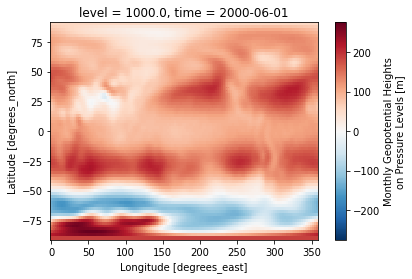

In [ ]:
# Fazendo um plot para dar uma olhada geral dos dados utilizando a opção:
# sel <- selection
# seleccionar a data no formato de string, em nosso caso vai ser 'YYYY-MM-DD'
# Lembrar do parâmetro "level" para os níveis de pressão 
ds_hgt['hgt'].sel(time='2000-06', level=1000).plot()
# 1 gpm <> 1 m geopotencial <> 0.98 J/Kg <> 0.98 mêtros dinâmicos
# 1 dm <> 10 m

In [ ]:
# Trnaformando o formato das longitudes de 0º-360º para -180º a +180º
ds_hgt.coords['lon'] = (ds_hgt.coords['lon'] + 180) % 360 - 180

# Ordenando o dataset baseado no novo formato da longitude -180º a +180º
# Lembrar da função <- ".sortby()"
ds_hgt = ds_hgt.sortby(ds_hgt.lon)

ds_hgt

<xarray.Dataset>
Dimensions:    (lat: 73, level: 17, lon: 144, nbnds: 2, time: 518)
Coordinates:
  * level      (level) float32 1e+03 925.0 850.0 700.0 ... 50.0 30.0 20.0 10.0
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2022-03-01
    hgt        (time, level, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

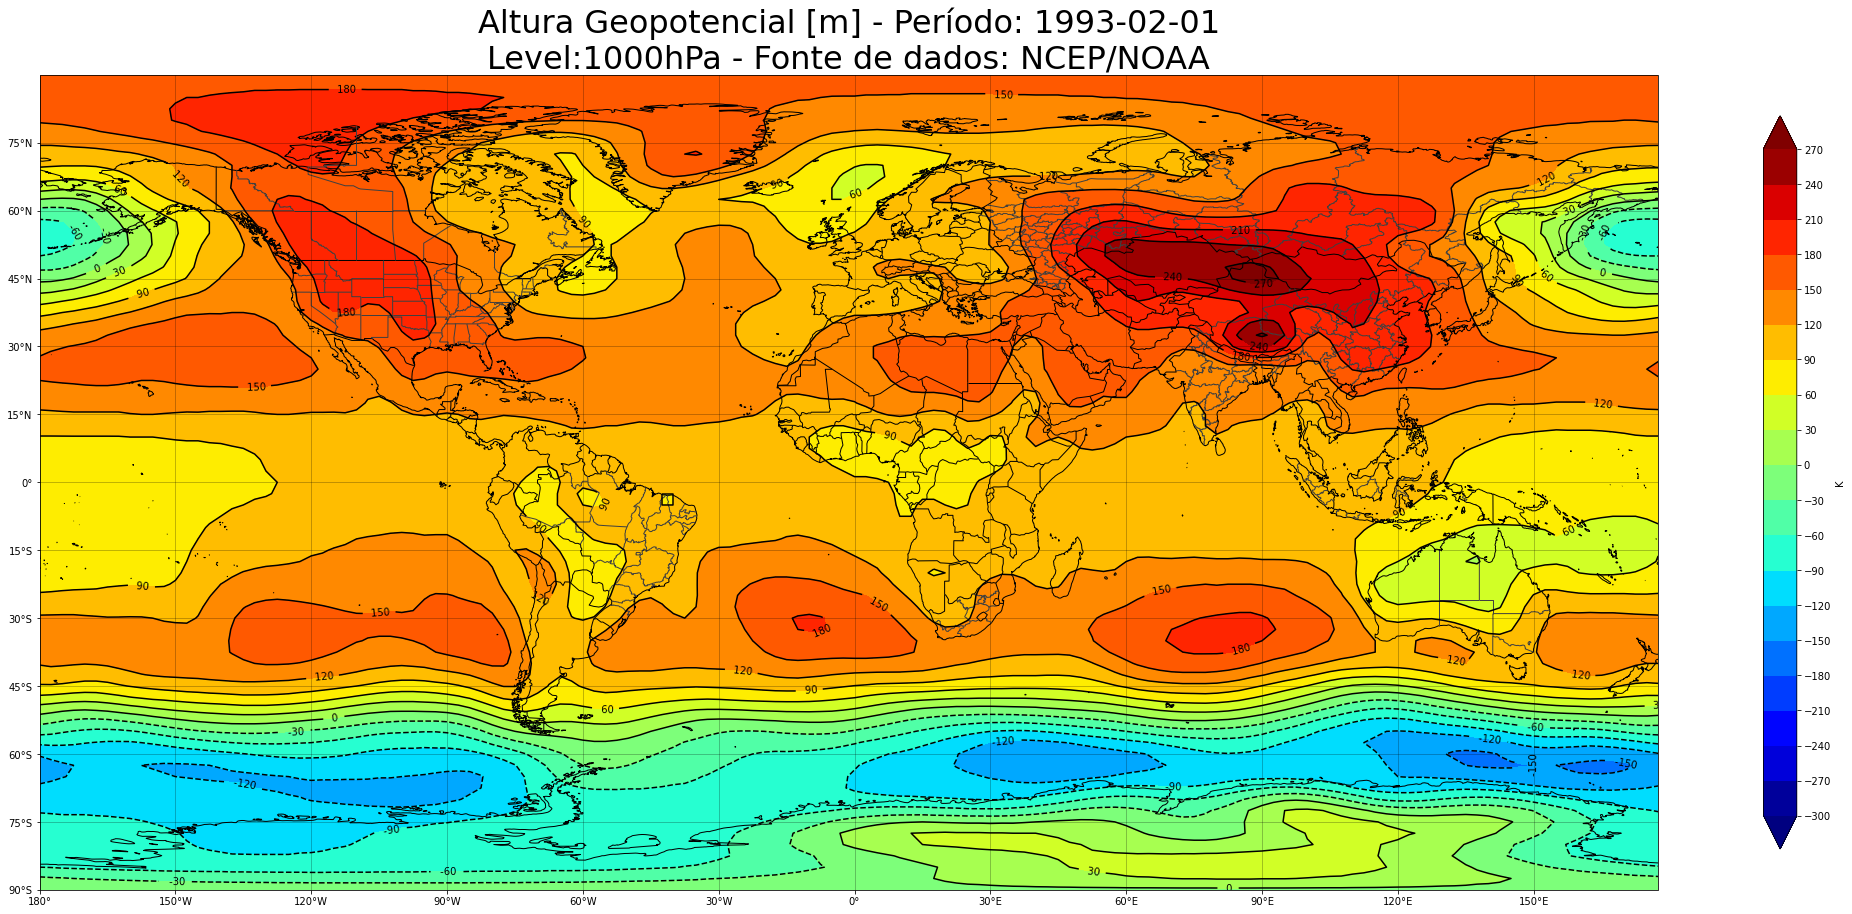

In [ ]:
# CRIANDO A FIGURA E FORMATANDO O PLOT COM O PACOTE CARTOPY

# Criando e ajustando o tamanho da figura
# Agregando a projeção cartográfica <- PlateCarree() <- Projeção cilíndrica equidistante

fig, ax = plt.subplots(figsize = (30,12), subplot_kw = {'projection': ccrs.PlateCarree()})

# Criando um array para formatar os límites dos eixos X e Y
# Lembrar de utilizar o pacote Numpy como <- np.arange
xticks = np.arange(-180,210,30)
yticks = np.arange(-90,90,15)

# FORMATANDO O PLOT COM AS FUNÇÕES DO CARTOPY
# Formatando os límites do eixo X <- Longitude <- .set_xticks()
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
# Formatando os límites do eixo Y <- Latitude <- set_yticks()
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
# Fazenddo o eixo X no formato de Latitude ºW <- .xaxis.set_major_formatter()
ax.xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS <- .yaxis.set_major_formatter()
ax.yaxis.set_major_formatter(LatitudeFormatter())

# AGREGANDO LINHAS DE COSTA, LÍMITES DOS PAISES E ESTADOS DO BRASIL
# Agregando linhas de costa com resolução de 50m <- .coastlines()
ax.coastlines('50m')
# Agregando os límites dos paises <- .add_feature()
ax.add_feature(cfeature.BORDERS)
# Agregando os estados do Brasil (mas também agrega os estados de The USA)
# Lembrar da função <- .cfeature.NaturalEarthFeature()
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
# Agregando linhas de grade
ax.grid(c='k', ls='-', alpha=0.3)
# Agregar os estados do Brasil No primer plot <- .add_feature()
ax.add_feature(states_provinces, edgecolor='0.25')

# Criando um array para a paleta de cores
# Lembrar do pacote Numpy, o rango de valores para a mslp [470, 1000, 20] <- np.arange()
colorb = np.arange(-300,300,30)

# Criando um gráfico com o formato de contornos
# Lembrar da função <- .contourf(lon, lat, data, levels, extend, cmap)
cf = ax.contourf(ds_hgt.lon, ds_hgt.lat, ds_hgt['hgt'].isel(time=0, level=0), levels=colorb, extend='both', cmap='jet')
# Lembrar da função <- .contour(lon, lat, data, levels, colors=['black'])
cb = ax.contour(ds_hgt.lon, ds_hgt.lat, ds_hgt['hgt'].isel(time=0, level=0), levels=colorb, colors = ['black'])

# Agregando os labels às linhas de contour
ax.clabel(
    cb,                        # Agregamos a variável com os contornos
    colors = ['black'],       # Cor dos labels dos valores dos contornos
    manual = False,           # Pôr os labels de forma automática frente à forma manual
    inline = True,            # Valores dentro da linha <- ----15------
    fmt = ' {:.0f}'.format,   # Labels como valores inteiros
    )

# Agregar título para o plot
ax.set_title('Altura Geopotencial [m] - Período: 1993-02-01\nLevel:1000hPa - Fonte de dados: NCEP/NOAA', size = 32)

# Paleta de cores no médio da figura
cbar = plt.colorbar(cf,ticks = colorb, label='K', orientation = 'vertical', shrink = 0.9, ax=ax) 

# ---------------------------------------------------------------------------------------------------------------------------

# Ordenando o espaçamento
plt.subplots_adjust(hspace = 1, top = 1)

# Menos espaços em branco
fig.tight_layout()

# Salvando a figura
fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_01/hgt_1000.png', format='png', dpi = 100)